# Librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



# Función

In [ ]:
brazos = {'brazo1': {'m': 1, 'd': 0.5},
        'brazo2': {'m': 2, 'd': 0.5},
        'brazo3': {'m': 1.5, 'd': 1.5}}

def reward(arm):
    try: 
        m = brazos[arm]['m']
        d = brazos[arm]['d']
        # Búsqueda en chatGPT "Cómo calculo un valor aleatorio a partir de una distribución normal con media y desviación estándar en python"
        retorno = np.random.normal(loc = m, scale = d)
    except Exception as e:
        print(e)

    return retorno

# Pruebas

## Simulación e histogramas 3 brazos

In [8]:
resultados = {'brazo1': [],
    'brazo2': [],
    'brazo3': []}

for _ in range(1000):
    for brazo in resultados:
        resultados[brazo].append(reward(brazo))

metricas = {'brazo1': {'m': 0, 'd': 0},
    'brazo2': {'m': 0, 'd': 0},
    'brazo3': {'m': 0, 'd': 0}}

for brazo, valores in resultados.items():
    metricas[brazo]['m'] = np.mean(valores)
    metricas[brazo]['d'] = np.std(valores)
    metricas[brazo]['v'] = np.var(valores)

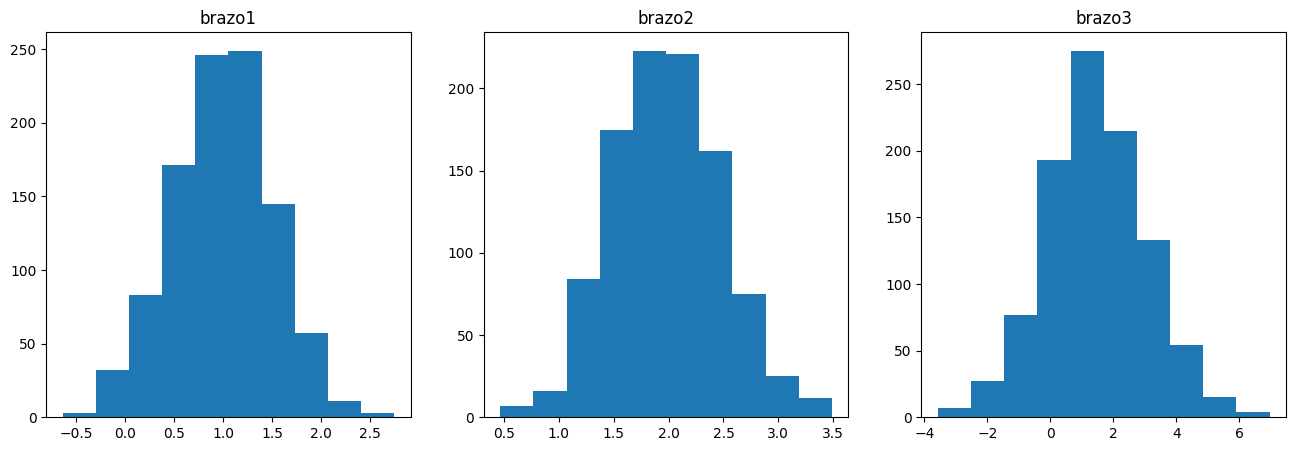

In [9]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))
i = 0
for brazo, valores in resultados.items():
    ax = axes[i]
    ax.hist(valores)
    ax.set_title(brazo)
    i += 1

## Cálculo de los qs y comparaciones

In [10]:
qs = {'brazo1': [],
    'brazo2': [],
    'brazo3': []}

for brazo in brazos:
    q = 0
    n = 1
    for r in resultados[brazo]:
        q = q + (r - q)/(n)
        n += 1
        qs[brazo].append(q)

In [11]:
resumen = pd.DataFrame({
    'Media real': {b: brazos[b]['m'] for b in brazos},
    'Desv. real': {b: brazos[b]['d'] for b in brazos},
    'Media estimada': {b: metricas[b]['m'] for b in brazos},
    'Desv. estimada': {b: metricas[b]['d'] for b in brazos},
    'Varianza': {b: metricas[b]['v'] for b in brazos},
    'Q inicial': {b: qs[b][0] for b in brazos},
    'Q final': {b: qs[b][-1] for b in brazos},
})
resumen.round(3)

,Media real,Desv. real,Media estimada,Desv. estimada,Varianza,Q inicial,Q final
brazo1,1.0,0.5,0.993,0.508,0.258,2.166,0.993
brazo2,2.0,0.5,1.979,0.497,0.247,1.266,1.979
brazo3,1.5,1.5,1.449,1.586,2.517,0.838,1.449


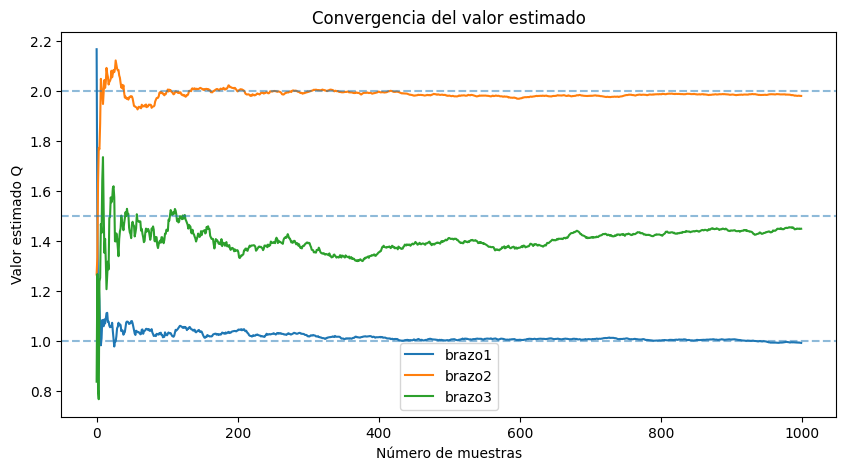

In [12]:
plt.figure(figsize=(10,5))

for brazo in brazos:
    plt.plot(qs[brazo], label=brazo)
    plt.axhline(brazos[brazo]['m'], ls='--', alpha=0.5)

plt.xlabel("Número de muestras")
plt.ylabel("Valor estimado Q")
plt.title("Convergencia del valor estimado")
plt.legend()
plt.show()

In [13]:
estadisticas = []

for brazo, valores in resultados.items():

    media = brazos[brazo]['m']     
    desv = brazos[brazo]['d']

    estadisticas.append({
        '< 0': np.sum(np.array(valores) < 0),
        '< media': np.sum(np.array(valores) < media),
        '< media - d': np.sum(np.array(valores) < (media - desv)),
    })

df_comp = pd.DataFrame(estadisticas, index = brazos.keys())
df_comp


,< 0,< media,< media - d
brazo1,27,492,173
brazo2,0,528,170
brazo3,170,528,170


# Interpretación

1. ¿Cuál máquina tuvo la mayor recompensa media estimada?

La máquina con la mayor recompensa estimada es la 2

2. ¿La máquina con mayor media estimada coincide con la de mayor media real?

Por recompensa media sí coinciden la estimada con la real

3. ¿Cuál presentó mayor desviación y varianza?

La de mayor desviación fue la tercera con 1.54 y varianza de 2.371

4. ¿Por qué A3 puede considerarse más riesgosa?

A3 es más riesgosa porque tiene la desviación estándar más grande, esto hace que pueda tomar valores más pequeños que las demás. De hecho en el histograma se ve que es la máquina con los valores más bajos (así también sea la que tiene los valores más altos), por lo que como tengo la probabilidad de obtener muy buena ganancia, tengo también una probabilidad más alta de tener valores mucho más bajos.

5. ¿Una recompensa individual alta implica que la máquina sea mejor?

No, dado que no muestra la realidad completa. Una recompensa individual en A3 podría ser mejor que en cualquiera de las otras, pero en el largo plazo se mostraría lo contrario.

6. ¿Cómo influye el tamaño de la muestra?

El tamaño de la muestra influye hasta cierto punto, dado que mientras más se pruebe, más se puede acercar el resultado al valor real, como se muestra en la gráfica, sin embargo, llega a un punto donde lo que aporta es muy poco. 

7. Si las medias fueran desconocidas, ¿cómo decidiría qué máquina elegir?

Realmente dependería mucho de la cantidad de pruebas que pudiera hacer, porque lo esperado sería ir probando en cada una y calculando esas medias para luego explotar la mejor, pero en la vida real habría limitantes para esto, como un capital o el tiempo.

8. ¿Qué cambiaría utilizando solamente 10 recompensas?

Probablemente sería mucho menos acertada ya que no alcanza al punto donde se empieza a estabilizar un poco. Dado que A3 tiene una mayor desviación estándar, si por alguna razón, alguno de los primeros 10 valores se quedan en los valores atípicos positivos y los demás cerca a la media, va a parecer que esta tiene una mayor esperanza media.

# Conclusiones

La máquina 2 es la mejor opción, ya que presentó la mayor recompensa media estimada y esta coincidió con su mayor recompensa media real.

La máquina 3 es la más riesgosa, debido a que presenta la mayor desviación estándar y varianza, lo que implica una mayor dispersión de sus recompensas.

El tamaño de la muestra es importante para obtener estimaciones confiables: a medida que aumentan las observaciones, la media estimada tiende a acercarse a la media real y a estabilizarse.

El número de pruebas y la variabilidad influyen en la elección del brazo. Con pocas observaciones, especialmente en máquinas como A3, una recompensa alta puede generar una estimación engañosa, por lo que es necesario equilibrar la exploración de las máquinas con la explotación de la que parece ofrecer mejores resultados.